In [ ]:
# ============================================================
# GC Content and Sequence Composition Analysis (Capstone Project)
# MSc Bioinformatics - Python-based Project
# ============================================================

#   Learning Objectives:
# - Read the FASTA file in Python (5 points)
# - Compute per-sequence GC content (15 points)
# - Compute and visualise sliding-window GC content for one sequence (20 points) 
# - Output summary statistics to file (20 points)
# - Interpret biological relevance (bonus: 10 points)


In [1]:
# ====================================
# 1. GENERATE RANDOM MULTI-FASTA FILE 
# ====================================

# This cell should be run before you start. 
# It creates the FASTA that you will work with.
# The file will be produced at the same location as your jupyter.
# You will be asked your FIRST and LAST name.
# The file will be named according to your name inputs.
# Each file has a different random set of sequences.
# There will be 10 sequences of 500 nucleotides each

import random

# For reproducibility you can fix or vary the random seed per run
random.seed()  # Each run creates a different file!

student_first_name = input("Enter your first name: ")
student_last_name = input("Enter your last name: ")


def generate_random_fasta(num_sequences=10, length=500, outfile="random_sequences.fasta"):
    """Generate a random multi-FASTA file of DNA sequences."""
    bases = ['A', 'T', 'G', 'C']
    with open(outfile, 'w') as f:
        for i in range(1, num_sequences + 1):
            seq_id = f">seq_{i}"
            seq = ''.join(random.choices(bases, k=length))
            f.write(seq_id + "\n")
            # write in lines of 60 bp for readability
            for j in range(0, length, 60):
                f.write(seq[j:j+60] + "\n")
    print(f"✅ Random FASTA file created: {outfile}")

# Generate the FASTA file
generate_random_fasta(num_sequences=10, length=500, outfile=f"{student_first_name}_{student_last_name}.fasta")


Enter your first name:  Athanasia
Enter your last name:  Kontse


✅ Random FASTA file created: Athanasia_Kontse.fasta


In [54]:
# =================
# 2. STUDENT TASKS
# =================

"""
==============================================
TASK 1 — READ THE FASTA FILE (5 points)
==============================================
1. Load the file "*.fasta".
2. Store sequences in a Python dictionary:
   {sequence_id: sequence_string}
3. Print the total number of sequences and their lengths.
"""

# 👉 STUDENT TO IMPLEMENT BELOW

Athanasia_Kontse= {} #create empty dictionary
with open("Athanasia_Kontse.fasta", "r") as file:
    for line in file:
        if line.startswith(">"): #remove fasta format characters in headers
            line = line.strip(">")
            line = line.strip("\n")
            sequence_id = (line)
            Athanasia_Kontse[sequence_id]= ""
        else:
            line = line.strip("\n") #remove new line character in seqs
            sequence_string= ""
            sequence_string += line
            Athanasia_Kontse[sequence_id] += sequence_string
            
print(Athanasia_Kontse) #check if it's correct
total_sequences= len(Athanasia_Kontse)

for sequence_id, sequences in Athanasia_Kontse.items(): #calculate len for each sequence
    sequence_length= len(sequences)
    print(f"Your sequence, {sequence_id} is {sequence_length} nucleotides long.")

{'seq_1': 'TACCATGGCAATATACGCGGAATGTTACGCACTTTCACGAGACGCGTAAACCGGCTCAAAGGCTTATGGTCTTGGCCGATATATAAACAGAGACAAATTACACTCGCACGCATCTTCACAGAAATGCCAACAAGAAAGCACAATGAGTACCTATAGCACACCGCGAGCCGTGACTCCGGCATATGTCGCCCAGGAAGAGGTAGCAAGTATCTGCTGTAACGGACACCTCCTAGGGGGAATTTTGCCCCCAGACTCACTGTAGCGCTTCCTCGCGTCAAATGACTTGCAGTATGTAAAACGCGATAGTATTTCACTCTACCTAGAGGGCCGGTTCCATTTGGCCGACATGCGAAAATTAATGCTGGGCTCACCCACCTAACGGAGGTAGTGACGAGCAGTCTGGGTAGTGAACCTTCATAACGCCTTGATCTGTGGCTATCGTGGCTTAGGCAAAGGGTGTCAGCTCGACGCTGGGGGGGCTGTTTCAGACCGTATTCTGA', 'seq_2': 'TTCTTTCAGGGCTGACACGAGTACGGTCTAGCACCCCGCCAGCGCCATTAAAGTCCAGTAGTGCACTTGCGACGCAGGATCAGAAGCCCGGGGCCCAACCCCAAATCTACTTTACGGTTTCACCGCGAGAACCCGTATATAGTGCCTCGGGTGTTCGGCCCGCAGACTCAGACCATGGTGGTTGAAACGGTAGCCCTGATGAACATTCACTGGGCGAATGCCGCACACAAACCTCCCTCGTCCAATCGACTTTAACTAGGGGATATTGACGGGTTCTACCTTTAACCTACTGTAACGGGCAATCGACTAGTACAGCGACCTTCGTGTTGAAATAGGCATGACAGCCTCGCTAATTCTCGATGAAATGGTTGAGCTACAAGTAGCTGTCTGTAGCTACTTGCGACGTTCTACGTAACTTGGTTTTGCATGAGAACGGACTTTACGAAAGTCCGACGTCGACATAGCGAATACCAAGT

In [9]:
"""
======================================================
TASK 2 — CALCULATE GC CONTENT PER SEQUENCE (15 points)
======================================================
1. For each sequence, compute:
   GC% = 100 * (G + C) / (A + T + G + C)
2. Store results in a DataFrame with columns:
   ['sequence_id', 'length', 'GC_percent']
3. Save as 'gc_summary.csv'
"""

# 👉 STUDENT TO IMPLEMENT BELOW

# example of the information that the "gc_summary.csv" should contain

import pandas as pd

GC_results = [] #create empty list

for sequence_id, sequence in Athanasia_Kontse.items(): #calculate nucleotide content in each sequence
    G = sequence.count("G")
    C = sequence.count("C")
    A = sequence.count("A")
    T = sequence.count("T")
    total_bases = A + T + G + C
    GC_content = 100 * (G + C) / total_bases
    print(f"Sequence {sequence_id} has GC-content of {GC_content}%")

    GC_results.append({
        "sequence_id" : sequence_id,
        "length" : sequence_length,
        "GC_percent" : GC_content  
}) #create a dictionary in the list with all the results

GC_results_df = pd.DataFrame(GC_results) #make it a dataframe
GC_results_df.to_csv("GC_summary.csv", index= False) #to prevent Dataframe index from appearing and creating an extra column
print("\nSuccessfully saved GC content summary to 'GC_summary.csv'.") #save as cvs
print(total_bases)


Sequence seq_1 has GC-content of 50.8%
Sequence seq_2 has GC-content of 50.4%
Sequence seq_3 has GC-content of 51.6%
Sequence seq_4 has GC-content of 45.2%
Sequence seq_5 has GC-content of 56.0%
Sequence seq_6 has GC-content of 52.8%
Sequence seq_7 has GC-content of 53.2%
Sequence seq_8 has GC-content of 54.0%
Sequence seq_9 has GC-content of 52.4%
Sequence seq_10 has GC-content of 53.2%

Successfully saved GC content summary to 'GC_summary.csv'.
500


In [ ]:

"""
=====================================================================================
TASK 3 — COMPUTE AND VISUALISE SLIDING-WINDOW GC CONTENT FOR ONE SEQUENCE (20 points)
=====================================================================================
1. For one sequence of your choice (e.g., 'seq_1'):
   - Compute GC% in a sliding window (window=50, step=10)
2. Plot GC% along sequence length.

The sliding-window approach is one of the most common analytical techniques in genomics and bioinformatics.
A sliding window is a fixed-size segment of the sequence that “slides” along the sequence one step at a time (or every n steps).

Parameter    Description                                              Example value
window       The length (in bp) of each window 
             (i.e. number of nucleotides analyzed together).                50
step         The distance (in bp) by which the window moves 
             between consecutive measurements.                              10

"""

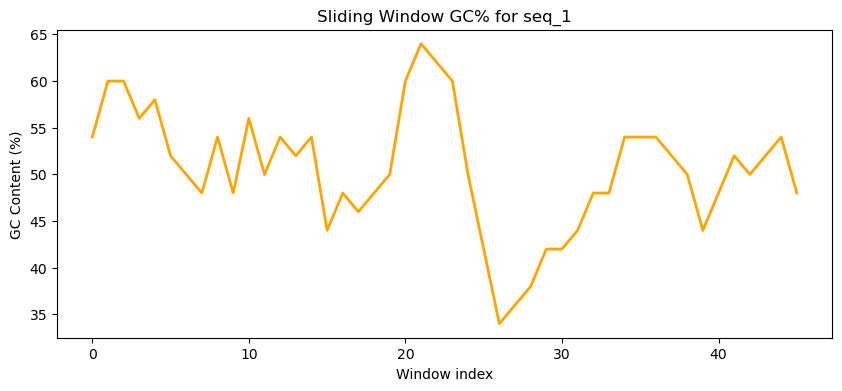

In [12]:
# Example of the produced plot
# notice there are 50 steps in the x-axis from the 500-nucleotide-long sequence
# this means you need to take the average GC of 50 consecutive nucleotides
# and move the window 10 nucleotides each time  (== 500bp long / 10bp window -> 50 steps)
# so the first measurement window is the GC average of nucleotides 1 - 51,
# the second measurement window is the GC average of nucleotides 11 - 61 and so on.


Sliding Window Results for 

    position  GC_percent
0          0        52.0
1         10        50.0
2         20        54.0
3         30        56.0
4         40        50.0
5         50        50.0
6         60        54.0
7         70        52.0
8         80        54.0
9         90        60.0
10       100        54.0
11       110        52.0
12       120        54.0
13       130        54.0
14       140        50.0
15       150        58.0
16       160        58.0
17       170        52.0
18       180        52.0
19       190        50.0
20       200        42.0
21       210        38.0
22       220        36.0
23       230        40.0
24       240        46.0
25       250        44.0
26       260        56.0
27       270        62.0
28       280        58.0
29       290        58.0
30       300        66.0
31       310        58.0
32       320        56.0
33       330        60.0
34       340        58.0
35       350        56.0
36       360        62.0
37       370        

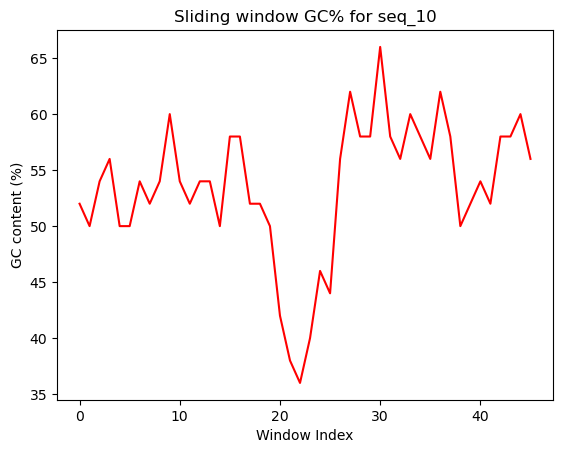

In [64]:
# 👉 STUDENT TO IMPLEMENT BELOW

#(window=50, step=10)

import pandas as pd
import matplotlib.pyplot as plt


GC_percentage_window_data = [] #create empty list for results
target_sequence = Athanasia_Kontse["seq_10"] #sequence of choice
window_size = 50
step_size = 10

for i in range(0, sequence_length - window_size + 1, step_size): #the range should be all the length- 50 + 1 for the window size to be 50 nucleotides 
    window = target_sequence[i : i + window_size] # starting at index i and going up to, but not including, the index i + window_size
    G_count = window.count("G")
    C_count = window.count("C")
    GC_percent_window = 100 * (G_count + C_count) / window_size #the percentage of G and C to the total number of nucleotides in that segment
    window_position = i # Record the starting index of the current window for plotting (X-axis position).
    GC_percentage_window_data.append({
        "position": window_position,
        "GC_percent": GC_percent_window
    })
        
GC_percentage_window_data_df = pd.DataFrame(GC_percentage_window_data)
print(f"""\nSliding Window Results for 

{GC_percentage_window_data_df}:""")

plt.plot(
    GC_percentage_window_data_df.index, # X-axis: Uses the default numerical index
    GC_percentage_window_data_df["GC_percent"], #Y-axis: Uses the calculated GC percentage for each window.
    color = "red"
)

plt.title("Sliding window GC% for seq_10")
plt.xlabel("Window Index")
plt.ylabel("GC content (%)")
plt.show()

In [ ]:

"""
=======================================
TASK 4 — SUMMARY STATISTICS (20 points) 
=======================================
1. For the totality of the 10 sequences, report:
   - Mean GC%
   - Standard deviation
   - Sequence with highest and lowest GC%
"""

In [52]:
# 👉 STUDENT TO IMPLEMENT BELOW

import pandas as pd

GC_percentages = GC_results_df["GC_percent"]
seq_names = GC_results_df["sequence_id"] 
GC_summary_statistics = []


GC_mean = GC_percentages.mean()     
GC_std = GC_percentages.std()

## to find the id of sequences with max and min
idx_highest = GC_percentages.idxmax() #to find which index number they have
idx_lowest = GC_percentages.idxmin()
GC_highest_seq_id = seq_names.loc[idx_highest] #to find the index location of id
GC_lowest_seq_id = seq_names.loc[idx_lowest]
GC_highest_value = GC_percentages.loc[idx_highest] #to find the index location of value
GC_lowest_value = GC_percentages.loc[idx_lowest]

GC_summary_statistics.append({
        "GC_mean (%)" : GC_mean,
        "GC_standard_deviation" : round(GC_std, 2),
        "GC_highest_seq" : GC_highest_seq_id,
        "GC_lowest_seq" : GC_lowest_seq_id,
        "GC_highest_value" : GC_highest_value,
        "GC_lowest_value" : GC_lowest_value
    }) #make a new dictionary with all the info

GC_summary_statistics_df = pd.DataFrame(GC_summary_statistics) #create a new dataframe
GC_summary_statistics_df.to_csv("GC_summary_statistics.csv", index= False) #to prevent Dataframe index from appearing and creating an extra column

In [ ]:
"""
TASK 5 - INTERPRETATION (10 bonus points)

Discuss possible biological interpretations:
   - Why might GC% vary?
   - How does GC relate to genome stability or species?
"""

#### 👉 STUDENT FREE TEXT BELOW

#### WRITE YOUR RESPONSE HERE

### 1. Why might GC% vary?
#### a) Directional mutation pressure
Enzymes responsible for DNA repair and replication exhibit a bias. They may favor inserting A/T pairs over G/C pairs or vice-versa during replication and repair.
<p><i> (Sueoka N. Directional mutation pressure, selective constraints, and genetic equilibria. J Mol Evol. 1992;34(2):95-114. doi:10.1007/BF00182387)</i>

#### b) Recombination (GC-biased gene conversion, gBGC)

In recombination occurs in specific regions an evolutionary process, called gBGC. It increases fixation alleles containing G or C, without taking into an account of these alleles effects on fitness.
<p><i> (Kostka D, Hubisz MJ, Siepel A, Pollard KS. The role of GC-biased gene conversion in shaping the fastest evolving regions of the human genome. 
Mol Biol Evol. 2012 Mar;29(3):1047-57. doi: 10.1093/molbev/msr279.)</i></p>

<p> That results in a distorted segregation favoring G and C over A and T alleles in highly recombining regions.</p>
<p><i> (Rousselle M, Laverré A, Figuet E, Nabholz B, Galtier N. Influence of Recombination and GC-biased Gene Conversion on the Adaptive and Nonadaptive Substitution Rate in Mammals versus Birds. Mol Biol Evol. 2019 Mar 1;36(3):458-471. doi: 10.1093/molbev/msy243.)</i></p>


#### c) Functional Constraints

Energy Efficiency: minimizing cellular costs. GC-rich mRNA sequences tend to encode cheaper amino acids.
Selection against stable mRNA: High GC creates stable secondary structures in the mRNA, which physically block the ribosome and impede the start of translation
<p><i> (Gao NL, He Z, Zhu Q, Jiang P, Hu S, Chen WH. Selection for Cheaper Amino Acids Drives Nucleotide Usage at the Start of Translation in Eukaryotic Genes. Genomics Proteomics Bioinformatics. 2021 Dec;19(6):949-957. doi: 10.1016/j.gpb.2021.03.002. Epub 2021 Mar 17.)</p>

#### d) Isochores (outdated by Graur)
Isochores:  long genomic regions in vertebrate genome forming neat "mosaic" of uniform blocks of GC content

<p><i> (Graur D. Slaying (Yet Again) the Brain-Eating Zombie Called the "Isochore Theory": A Segmentation Algorithm Used to "Confirm" the Existence of Isochores Creates "Isochores" Where None Exist. Int J Mol Sci. 2022 Jun 12;23(12):6558. doi: 10.3390/ijms23126558. </i></p>

### 2. How does GC relate to genome stability or species? 
#### a) Genome Stability 
Genome stability is thermodynamically enhanced by higher GC content because Guanine-Cytosine base pairs have three hydrogen bonds compared to the Adenine-Thymine that have two. Thermophilic taxa probably have higher GC content.
<p><i> (Mou Q-H, Hu Z, Zhang J, Daroch M and Tang J (2025) Comparative genomics of thermosynechococcaceae and thermostichaceae: insights into codon usage bias. Acta Biochim. Pol 71:13825. doi: 10.3389/abp.2024.13825)</i></p>

Genome stability can also be affected by oxidative damage. Higher GC content generally correlates with increased susceptibility to oxidative damage.
The deaminated product of C is U. If this U base is not immediately detected and repaired it will be treated as T and paired with A. Luckily, in GC-rich regions like exons and promoters protection from damage can be found due to the diverse accessibility of DNA.

<p><i> (Poetsch, A.R., Boulton, S.J. & Luscombe, N.M. Genomic landscape of oxidative DNA damage and repair reveals regioselective protection from mutagenesis. Genome Biol 19, 215 (2018). https://doi.org/10.1186/s13059-018-1582-2)</i></p>


#### b) Species Identification and Classification
Especially for Procaryotes the GC content of the entire genome GC is typically a stable characteristic that is relatively constant within a species but can vary widely  between different species or genera. Some guidelines require organisms classified as the same species to have a GC content that is very close.

<p><i> (Noha M. Mesbah, William B. Whitman, Mostafa Mesbah,
14 - Determination of the G+C Content of Prokaryotes, Editor(s): Fred Rainey, Aharon Oren, Methods in Microbiology, Academic Press,
Volume 38, 2011, Pages 299-324, ISSN 0580-9517, ISBN 9780123877307, https://doi.org/10.1016/B978-0-12-387730-7.00014-0.) </i></p>


